In [573]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# **Task 1: Data Loading and Pre-processing**

In [574]:
# Load dataset
df = pd.read_csv("student_dataset.csv")

In [575]:
# Display first 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,Student_ID,Gender,Age,ParentEducation,StudyHoursPerWeek,AttendanceRate,InternetAccess,MidtermScore,FinalScore
0,1,Female,22,Master's,10.3,97.36,No,40.61,59.61
1,2,Male,18,High School,27.1,97.71,No,57.27,74.00
2,3,Male,24,High School,12.4,99.52,No,41.84,63.85
3,4,Female,24,High School,25.5,90.38,Yes,45.65,44.44
4,5,Female,23,Master's,13.3,59.41,No,53.13,61.77


In [576]:
# Check missing values
print("\nMissing values:")
df.isnull().sum()


Missing values:


Student_ID            0
Gender                0
Age                   0
ParentEducation      98
StudyHoursPerWeek     0
AttendanceRate        0
InternetAccess        0
MidtermScore          0
FinalScore            0
dtype: int64

### **Handle missing values**

In [577]:
# For numeric columns -> fill with median
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [578]:
# For categorical columns -> fill with mode
categorical_columns = df.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [579]:
df = df.drop(columns=['Student_ID'])

In [580]:
# Check missing values again
print("\nMissing values:")
df.isnull().sum()


Missing values:


Gender               0
Age                  0
ParentEducation      0
StudyHoursPerWeek    0
AttendanceRate       0
InternetAccess       0
MidtermScore         0
FinalScore           0
dtype: int64

### **Create Target Variable**

In [581]:
# Result = 1 if FinalScore >= 50
# Result = 0 if FinalScore < 50
target = np.where(df['FinalScore']>=50, 1, 0)
df['Result'] = target

print("\nTarget distribution:")
print(df["Result"].value_counts())
df.sample(10)


Target distribution:
Result
1    421
0     79
Name: count, dtype: int64


,Gender,Age,ParentEducation,StudyHoursPerWeek,AttendanceRate,InternetAccess,MidtermScore,FinalScore,Result
155,Male,21,PhD,15.4,97.55,No,45.05,77.15,1
131,Female,21,PhD,21.8,93.47,Yes,86.96,96.85,1
226,Male,22,Master's,26.5,99.88,No,98.25,93.15,1
327,Female,22,Bachelor's,18.0,69.22,Yes,40.26,58.67,1
490,Male,21,High School,5.3,69.44,No,70.44,93.31,1
491,Female,19,PhD,15.7,55.96,No,47.77,74.39,1
167,Female,18,Master's,6.1,91.99,Yes,67.80,65.85,1
35,Female,23,Bachelor's,21.4,73.23,No,79.58,43.60,0
464,Female,22,Master's,19.1,64.81,No,51.41,90.47,1
195,Male,18,High School,23.9,72.34,Yes,99.68,82.71,1


#### **Encode Categorical Columns**

In [582]:
#Find Unique Parent Education
df['ParentEducation'].unique()

array(["Master's", 'High School', 'PhD', "Bachelor's"], dtype=object)

In [583]:
gender_le = LabelEncoder()
internet_le = LabelEncoder()
education_order = [
    ["Master's", 'High School', 'PhD', "Bachelor's"]
]
encoder = OrdinalEncoder(categories=education_order)

df['ParentEducation'] = encoder.fit_transform(
    df[['ParentEducation']]
)
df['Gender'] = gender_le.fit_transform(df['Gender'])
df['InternetAccess'] = internet_le.fit_transform(df['InternetAccess'])

#### **Separate Features and Target**

In [584]:
y = df["Result"]
X = df.drop(columns=["FinalScore", "Result"])

In [585]:
df

,Gender,Age,ParentEducation,StudyHoursPerWeek,AttendanceRate,InternetAccess,MidtermScore,FinalScore,Result
0,0,22,0.0,10.3,97.36,0,40.61,59.61,1
1,1,18,1.0,27.1,97.71,0,57.27,74.00,1
2,1,24,1.0,12.4,99.52,0,41.84,63.85,1
3,0,24,1.0,25.5,90.38,1,45.65,44.44,0
4,0,23,0.0,13.3,59.41,0,53.13,61.77,1
...,...,...,...,...,...,...,...,...,...
495,1,19,3.0,12.0,74.43,0,49.53,95.86,1
496,1,24,1.0,20.1,85.07,1,52.37,86.50,1
497,1,20,3.0,14.5,99.32,1,99.52,96.45,1
498,1,23,1.0,10.8,72.08,1,85.19,58.14,1


#### **Train-Test Split**

In [586]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

#### **Scale Numeric Features**

In [587]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#### **Train the Model using LogisticRegression**

In [588]:
model = LogisticRegression()
model.fit(X_train, y_train)
print("\nModel training completed.")


Model training completed.


# **Task 3: Model Evaluation**

In [589]:
y_pred = model.predict(X_test)

ac = accuracy_score(y_test, y_pred)
pr = precision_score(y_test, y_pred)
rc = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Accuarcy Score is   : {ac:.2f}")
print(f"Precision Score is  : {pr:.2f}")
print(f"Recall Score is     : {rc:.2f}")
print(f"Confusion metric is :\n {cm}")

Accuarcy Score is   : 0.86
Precision Score is  : 0.86
Recall Score is     : 1.00
Confusion metric is :
 [[ 0 14]
 [ 0 86]]


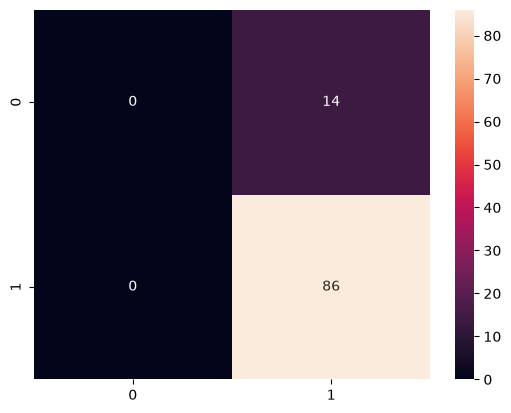

In [590]:
sns.heatmap(cm, annot=True)
plt.show()

In [591]:
df

,Gender,Age,ParentEducation,StudyHoursPerWeek,AttendanceRate,InternetAccess,MidtermScore,FinalScore,Result
0,0,22,0.0,10.3,97.36,0,40.61,59.61,1
1,1,18,1.0,27.1,97.71,0,57.27,74.00,1
2,1,24,1.0,12.4,99.52,0,41.84,63.85,1
3,0,24,1.0,25.5,90.38,1,45.65,44.44,0
4,0,23,0.0,13.3,59.41,0,53.13,61.77,1
...,...,...,...,...,...,...,...,...,...
495,1,19,3.0,12.0,74.43,0,49.53,95.86,1
496,1,24,1.0,20.1,85.07,1,52.37,86.50,1
497,1,20,3.0,14.5,99.32,1,99.52,96.45,1
498,1,23,1.0,10.8,72.08,1,85.19,58.14,1


# **Task 4: Model Save**

#### **Save Model**

In [592]:

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully.")

Model saved successfully.


#### **Reload Model**

In [593]:
with open("model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model reloaded successfully.")

Model reloaded successfully.


In [594]:
sample = X_test[0].reshape(1, -1)

prediction = loaded_model.predict(sample)

print("\nTest Prediction:")

if prediction[0] == 1:
    print("Result: Pass")
else:
    print("Result: Fail")


Test Prediction:
Result: Pass
